# WBC 中華隊賽事 PTT 留言分析為資料來源

## 第十組 組員
N134020005 陳彥廷<br>
N134020011 林士欽<br>
N134320001 史卯郁<br>
N134320005 張智絢<br>
N134320024 林曉君<br>
N134320029 周書緯

## Notebook 主要流程

1. 讀取與檢查資料
2. 整理文章與留言欄位
3. 清理文字並進行中文斷詞
---
4. word2vec
*   建立模型
*   查找最相關的字
*   畫出２維的散佈圖
*   畫出３Ｄ散狀圖
*   將字做分群
5. Transformers Embeddings
*   使用 Sentence-Transformer 套件
*   使用 bert-base-chinese 模型（使用embedding做NLP任務）
*   資料集中前五相似的文章
6. 實際應用
*   我想找本次經典賽討論 "教練調度" 相關文章

    => 建立一個互動式函數，輸入文字後即可從資料集中搜尋最相似的文章（查詢文字: 哪位教練調度最好）

*   我是台灣隊球迷，我想在經典賽前follow本次'台灣打擊'狀況

    => 輸入語句找每日相似文章（分析關鍵字: '台灣打擊' 從 2026-02-28 到 2026-03-07）

7. Token classification<br>
  7.1 NER<br>
8. Sequence classification<br>
  8.1 Sentiment Classification<br>
  8.2 Relation Extraction (RE)<br>
9. Text Clustering<br>
  9.1 BERTopic 基本用法介紹<br>
  9.2 BERTopic 的 Embedding model<br>
  9.3 BERTopic 的 Clustering model<br>
  9.4 套用中文資料

In [1]:
import os

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
os.chdir('/content/drive/MyDrive/中山大學/SMA_2026S-main/week11') # 請將此處替換為您在 Google Drive 中的實際資料夾路徑
os.listdir() #確認目錄內容

['社媒第三次讀書會_智絢.ipynb',
 'classification_with_embeddings.ipynb',
 'TaipeiSansTCBeta-Regular.ttf',
 'raw_data',
 'dict',
 'tmunlp_1.6B_WB_50dim_2020v1.bin.gz',
 'text_embeddings.ipynb',
 'Gimini.gdoc']

In [3]:
!pip install jieba
!pip install "gensim==4.3.3" "spacy==3.7.2" "thinc==8.2.2"

In [ ]:
# 先清除舊的 numpy
#!pip uninstall -y numpy

# 安裝對應版本
#!pip install numpy==1.26.4 gensim==4.3.3 spacy==3.7.2 thinc==8.2.2

# 強制重啟 Runtime
#import os
#os.kill(os.getpid(), 9)

In [4]:
import pandas as pd
import jieba
import jieba.analyse
import re
import numpy as np # Added this line
from collections import defaultdict
import multiprocessing

from gensim.models.phrases import Phrases, Phraser
from gensim.models import Word2Vec, KeyedVectors

from gensim.models import Word2Vec

import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import seaborn as sns
import torch

from matplotlib.font_manager import fontManager
import plotly.express as px

sns.set_style("darkgrid")

/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:44: SyntaxWarning: invalid escape sequence '\.'
  re_han_default = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._%\-]+)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/__init__.py:46: SyntaxWarning: invalid escape sequence '\s'
  re_skip_default = re.compile("(\r\n|\s)", re.U)
/usr/local/lib/python3.12/dist-packages/jieba/finalseg/__init__.py:78: SyntaxWarning: invalid escape sequence '\.'
  re_skip = re.compile("([a-zA-Z0-9]+(?:\.\d+)?%?)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:16: SyntaxWarning: invalid escape sequence '\.'
  re_skip_detail = re.compile("([\.0-9]+|[a-zA-Z0-9]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:17: SyntaxWarning: invalid escape sequence '\.'
  re_han_internal = re.compile("([\u4E00-\u9FD5a-zA-Z0-9+#&\._]+)")
/usr/local/lib/python3.12/dist-packages/jieba/posseg/__init__.py:18: SyntaxWarning: invalid escape sequence '\s'
  re_skip_internal = re.compil

In [5]:
import os
# 設定繁體中文詞庫

# 1. 定義基礎路徑 (建議使用絕對路徑避免混淆)
base_path = '/content/drive/MyDrive/中山大學/SMA_2026S-main/week11'

# 2. 設定詞庫路徑
dict_path = os.path.join(base_path, 'dict/dict.txt.big')
user_dict_path = os.path.join(base_path, 'dict/user_dict.txt')
stopword_path = os.path.join(base_path, 'dict/stopwords.txt')

# 3. 載入 jieba 設定
jieba.set_dictionary(dict_path)
jieba.load_userdict(user_dict_path)

# 4. 讀取 stopwords
with open(stopword_path, 'r', encoding='utf-8') as f:
    stopWords = [line.strip() for line in f.readlines()]

Building prefix dict from /content/drive/MyDrive/中山大學/SMA_2026S-main/week11/dict/dict.txt.big ...
DEBUG:jieba:Building prefix dict from /content/drive/MyDrive/中山大學/SMA_2026S-main/week11/dict/dict.txt.big ...
Dumping model to file cache /tmp/jieba.u02da0a2c6f2d9d35f746c5fde228c877.cache
DEBUG:jieba:Dumping model to file cache /tmp/jieba.u02da0a2c6f2d9d35f746c5fde228c877.cache
Loading model cost 2.681 seconds.
DEBUG:jieba:Loading model cost 2.681 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


In [6]:
# 斷詞函式
def getToken(row):
    seg_list = jieba.lcut(row)
    seg_list = [w for w in seg_list if w not in stopWords and len(w)>1] # 篩選掉停用字與字元數小於1的詞彙

    return seg_list

In [7]:
# 讀入中文示範資料集

PttWbcStopWordPath = os.path.join(base_path, 'raw_data/ptt_wbc_noStop_df.csv')
origin_data = pd.read_csv(PttWbcStopWordPath)

In [ ]:
metaData = origin_data
metaData.head(2)

,artTitle,artDate,artCatagory,cmtStatus,cmtDate,cmtContent,tokens_filtered,word
0,[分享] MLB官網列出WBC每隊的關鍵球員,2026-02-19 00:13:52,棒球,→,2026-02-19 00:15:00+08:00,: 選近藤是因為可能會排在大谷後面嗎,"['選', '近藤', '會排', '大谷', '後面']",選 近藤 會排 大谷 後面
1,[分享] MLB官網列出WBC每隊的關鍵球員,2026-02-19 00:13:52,棒球,推,2026-02-19 00:19:00+08:00,: 希望徐的好表現讓大聯盟後悔沒簽下來,"['希望', '徐若熙', '表現', '後悔', '簽下']",希望 徐若熙 表現 後悔 簽下


#　4. word2vec

####（1）如何自己訓練word2vec模型

實際應用在資料集上

In [ ]:
# Ensure 'word' column contains only strings and split them into lists of words for all rows
# Handle NaN values by converting them to empty lists to maintain consistent length
processed_words_series = metaData['word'].apply(lambda x: str(x).split() if pd.notna(x) else [])
sents = processed_words_series.to_list()

bigrams = Phrases(sents, min_count=1, threshold=1000)
bigram_phrasers = Phraser(bigrams)

# Apply the phraser to get bigrams
# Create a copy to avoid SettingWithCopyWarning if metaData is a view
metaData_copy = metaData.copy()
metaData_copy['word_list_bigrams'] = list(bigram_phrasers[sents])

# Update metaData with the new column (or just use metaData_copy from now on)
metaData = metaData_copy

metaData.head(2)

,artTitle,artDate,artCatagory,cmtStatus,cmtDate,cmtContent,tokens_filtered,word,word_list_bigrams
0,[分享] MLB官網列出WBC每隊的關鍵球員,2026-02-19 00:13:52,棒球,→,2026-02-19 00:15:00+08:00,: 選近藤是因為可能會排在大谷後面嗎,"['選', '近藤', '會排', '大谷', '後面']",選 近藤 會排 大谷 後面,"[選, 近藤, 會排, 大谷, 後面]"
1,[分享] MLB官網列出WBC每隊的關鍵球員,2026-02-19 00:13:52,棒球,推,2026-02-19 00:19:00+08:00,: 希望徐的好表現讓大聯盟後悔沒簽下來,"['希望', '徐若熙', '表現', '後悔', '簽下']",希望 徐若熙 表現 後悔 簽下,"[希望, 徐若熙, 表現, 後悔, 簽下]"


In [ ]:
word_freq = defaultdict(int)
# 計算詞頻
sents = metaData['word_list_bigrams'].tolist()
for sent in sents: # sent 中的每個句子
    for i in sent: # i 是句子中的每個字
        word_freq[i] += 1

In [ ]:
print(f"total unique words in sentences: {len(word_freq)}")
sorted(word_freq, key=word_freq.get, reverse=True)[:10]

total unique words in sentences: 116263


['韓國', '台灣', '日本', '說', '澳洲', '晉級', '推', '想', '美國', '大谷']

In [ ]:
print(f"sentence number of corpus: {len(sents)}")
i = 0
for sent in sents:
    i = i + len(sent)
print(f"average length of sentences: {i/len(sents)}")

sentence number of corpus: 571991
average length of sentences: 3.6428842411856133


Word2Vec 計算

In [ ]:
# 環境變數設定
%env PYTHONHASHSEED=2025

env: PYTHONHASHSEED=2025


In [ ]:
# 查看機器的core
cores = multiprocessing.cpu_count()
print(f"number of cores: {cores}")

number of cores: 2


In [ ]:
# 建立模型
w2v_model = Word2Vec(sents,
                     min_count=60,# 小於30次tf的字會被刪除
                     window=5,# 往左右各2的距離
                     vector_size=128,# vector 的維度
                     sample=0.005,# 愈小的話，高tf的字會不容易被選到
                     alpha=0.001,# learning rate
                     min_alpha=0.0005, # 迭代到最小的learning rate，learning rate會慢慢下降至min_alpha
                     negative=0,
                     workers=cores-1, # 用的cpu資源
                     seed=8787,
                     sg = 1,# 0/1 是否使用skip gram
                     epochs= 30,
                     hs=1 , # hierarchical softmax
                     )

In [ ]:
# 檢查最相關的字
w2v_model.wv.most_similar('日本',topn=10)

[('日韓', 0.5392444729804993),
 ('多明尼加', 0.48762285709381104),
 ('以前', 0.44744330644607544),
 ('陣容', 0.4119119346141815),
 ('四強', 0.39461609721183777),
 ('預賽', 0.38317203521728516),
 ('日', 0.38184982538223267),
 ('日本人', 0.3815714120864868),
 ('多委', 0.3560646176338196),
 ('日職', 0.3549792170524597)]

In [ ]:
w2v_model.wv.most_similar('台灣',topn=10)

[('臺灣', 0.7292880415916443),
 ('台灣人', 0.6371508836746216),
 ('亞洲', 0.4520193338394165),
 ('中華', 0.45196592807769775),
 ('國家', 0.44296184182167053),
 ('中國', 0.41097894310951233),
 ('世界', 0.40396779775619507),
 ('CT', 0.39720073342323303),
 ('只會', 0.3919799029827118),
 ('韓國人', 0.36133959889411926)]

In [ ]:
w2v_model.wv.most_similar('韓國',topn=10)

[('南韓', 0.847931444644928),
 ('爽', 0.47246336936950684),
 ('贏', 0.4714309275150299),
 ('韓國人', 0.46469274163246155),
 ('日韓', 0.44090884923934937),
 ('100分', 0.4115442633628845),
 ('韓', 0.4057316184043884),
 ('晉級', 0.3951306641101837),
 ('澳洲', 0.39089176058769226),
 ('下來', 0.3888261318206787)]

In [ ]:
w2v_model.wv.most_similar(['台灣','啦啦隊'],topn=10)

[('台灣人', 0.6187151670455933),
 ('臺灣', 0.6067822575569153),
 ('國家', 0.49175822734832764),
 ('國內', 0.4847799241542816),
 ('經濟', 0.4815479516983032),
 ('政府', 0.45887476205825806),
 ('進步', 0.45600658655166626),
 ('韓職', 0.45057913661003113),
 ('亞洲', 0.4494543671607971),
 ('環境', 0.4426664113998413)]

In [ ]:
w2v_model.wv.most_similar(['台灣','隊長'],topn=10)

[('臺灣', 0.5964269042015076),
 ('費神', 0.48502951860427856),
 ('謝謝', 0.4842846095561981),
 ('四爺', 0.4824824333190918),
 ('龍哥', 0.47398674488067627),
 ('真心', 0.4563238322734833),
 ('台灣人', 0.4164641201496124),
 ('早日_康復', 0.4121564030647278),
 ('英雄_命', 0.4011092782020569),
 ('政禹', 0.4004543125629425)]

In [ ]:
# 跟兩個字最不相關
w2v_model.wv.most_similar(negative=['台灣','邁阿密'],topn=10)

[('好爛', 0.35514333844184875),
 ('超爛', 0.3206830322742462),
 ('雷', 0.296340674161911),
 ('跑掉', 0.2906152009963989),
 ('得點_圈', 0.2889934182167053),
 ('炸裂', 0.2868705689907074),
 ('判斷', 0.2860164940357208),
 ('擊球_初速', 0.27549633383750916),
 ('初速', 0.2716103196144104),
 ('扯', 0.26429933309555054)]

In [ ]:
# 計算兩個字之間的關係
w2v_model.wv.similarity("台灣","邁阿密")

0.090812504

In [ ]:
w2v_model.wv.similarity("台灣","淘汰")

0.072651565

In [ ]:
w2v_model.wv.similarity("台灣","晉級")

0.11828043

In [ ]:
w2v_model.wv.similarity("台灣","加油")

-0.07165402

In [ ]:
# 比較字詞間，誰最不相關（邊緣）
w2v_model.wv.doesnt_match(["台灣", "晉級", '啦啦隊'])

'晉級'

In [ ]:
# 相對關係
w2v_model.wv.most_similar(positive=["台灣"], negative=["晉級"], topn=5)

[('臺灣', 0.4285290837287903),
 ('台灣人', 0.41788554191589355),
 ('老婆', 0.3246254622936249),
 ('謝謝', 0.32260316610336304),
 ('時代', 0.3186143636703491)]

In [ ]:
# 取得所有的字
words = w2v_model.wv.key_to_index.keys()

視覺化字之間的關係及將字做分群

In [ ]:
# 降維：利用PCA tSNE

def reduceDim(mat,method:str='PCA',dim:str=2,perplexity = 25,learning_rate = 400):

    method_dict = {
        "PCA":PCA(n_components=dim,iterated_power = 1000,random_state=0),
        "TSNE":TSNE(n_components=dim,random_state=0,perplexity=perplexity,learning_rate=learning_rate),
    }
    new_feat = method_dict[method].fit_transform(mat)

    return new_feat

In [ ]:
# 拿到list of words 的vector
def getVecs(model,words:list):
    vecs = []
    for i in words:
        vecs.append(model.wv[i])
    return np.vstack(vecs)

In [ ]:
getVecs(w2v_model,['台灣','晉級'])

array([[ 2.86580831e-01, -2.19177827e-02, -2.50241071e-01,
         3.23665529e-01,  8.99633914e-02,  2.67143399e-01,
        -2.96451617e-03,  3.01517602e-02,  6.21610917e-02,
        -1.55499965e-01,  6.19233958e-02,  2.73684472e-01,
         2.56060541e-01,  4.18819159e-01, -2.06359461e-01,
         5.47832131e-01,  4.25913953e-04, -1.47709101e-01,
         1.71518140e-02, -3.46258521e-01, -1.11044701e-02,
         3.62220854e-01, -4.34274048e-01,  4.47340280e-01,
         5.55395149e-04, -1.38329253e-01,  1.12867162e-01,
         8.44717249e-02, -1.66032612e-01,  2.82381386e-01,
        -9.32573806e-03,  1.23567089e-01,  6.29539639e-02,
        -3.33625197e-01,  1.41369388e-01, -2.58640319e-01,
        -6.64696544e-02, -3.82958412e-01, -3.71699929e-01,
        -2.42508143e-01, -3.79784703e-01,  1.23152889e-01,
         4.53184366e-01,  3.41608733e-01, -2.97523022e-01,
        -1.04334362e-01, -4.11640629e-02, -3.34993303e-01,
         7.00795889e-01, -3.35765749e-01,  2.73591340e-0

擴展相似的字詞(還沒做)

In [ ]:
# 畫出兩維的散佈圖
def plotScatter(vec_df, hue_column=None):
    """
    vec_df: 字詞及其兩個維度的值
    hue_column: 用於顏色分類的欄位名稱 (e.g., 'cluster')
    """

    # 1. 定義基礎路徑 (建議使用絕對路徑避免混淆)
    base_path = '/content/drive/MyDrive/中山大學/SMA_2026S-main/week11'

    # 2. 設定詞庫路徑
    ttf_path = os.path.join(base_path, 'TaipeiSansTCBeta-Regular.ttf')

    plt.figure(figsize=(15,15))
    fontManager.addfont(ttf_path)
    plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']
    plt.rcParams['font.size'] = '16'

    p = sns.scatterplot(x="dim1", y="dim2",
                  data=vec_df, hue=hue_column, palette='viridis' if hue_column else None)
    for line in range(0, vec_df.shape[0]):
         p.text(vec_df["dim1"][line],
                 vec_df['dim2'][line],
                 '  ' + vec_df["word"][line].title(),
                 horizontalalignment='left',
                 verticalalignment='bottom', size='medium',
                 weight='normal'
                ).set_size(15)
    plt.title('Word Embeddings Visualization' + (f' (Clustered)' if hue_column else ''))
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.show()

# 畫出三維的散佈圖
def plotScatter3D(vec_df):
    vec_df['size'] = .5
    if 'color' not in vec_df.columns:
        vec_df['color'] = 'blue'
    fig = px.scatter_3d(
        vec_df,'dim1','dim2','dim3',text = 'word',width=800, height=800,color = 'color',size = 'size'

    )

    fig.show()

In [ ]:
sample_words = np.random.choice(list(words),300,replace=False).tolist()

feat = getVecs(model=w2v_model,words=sample_words)
print(feat.shape)
new_feat = reduceDim(feat,method='TSNE',perplexity=20,learning_rate = 800)
print(new_feat.shape)

(300, 128)
(300, 2)


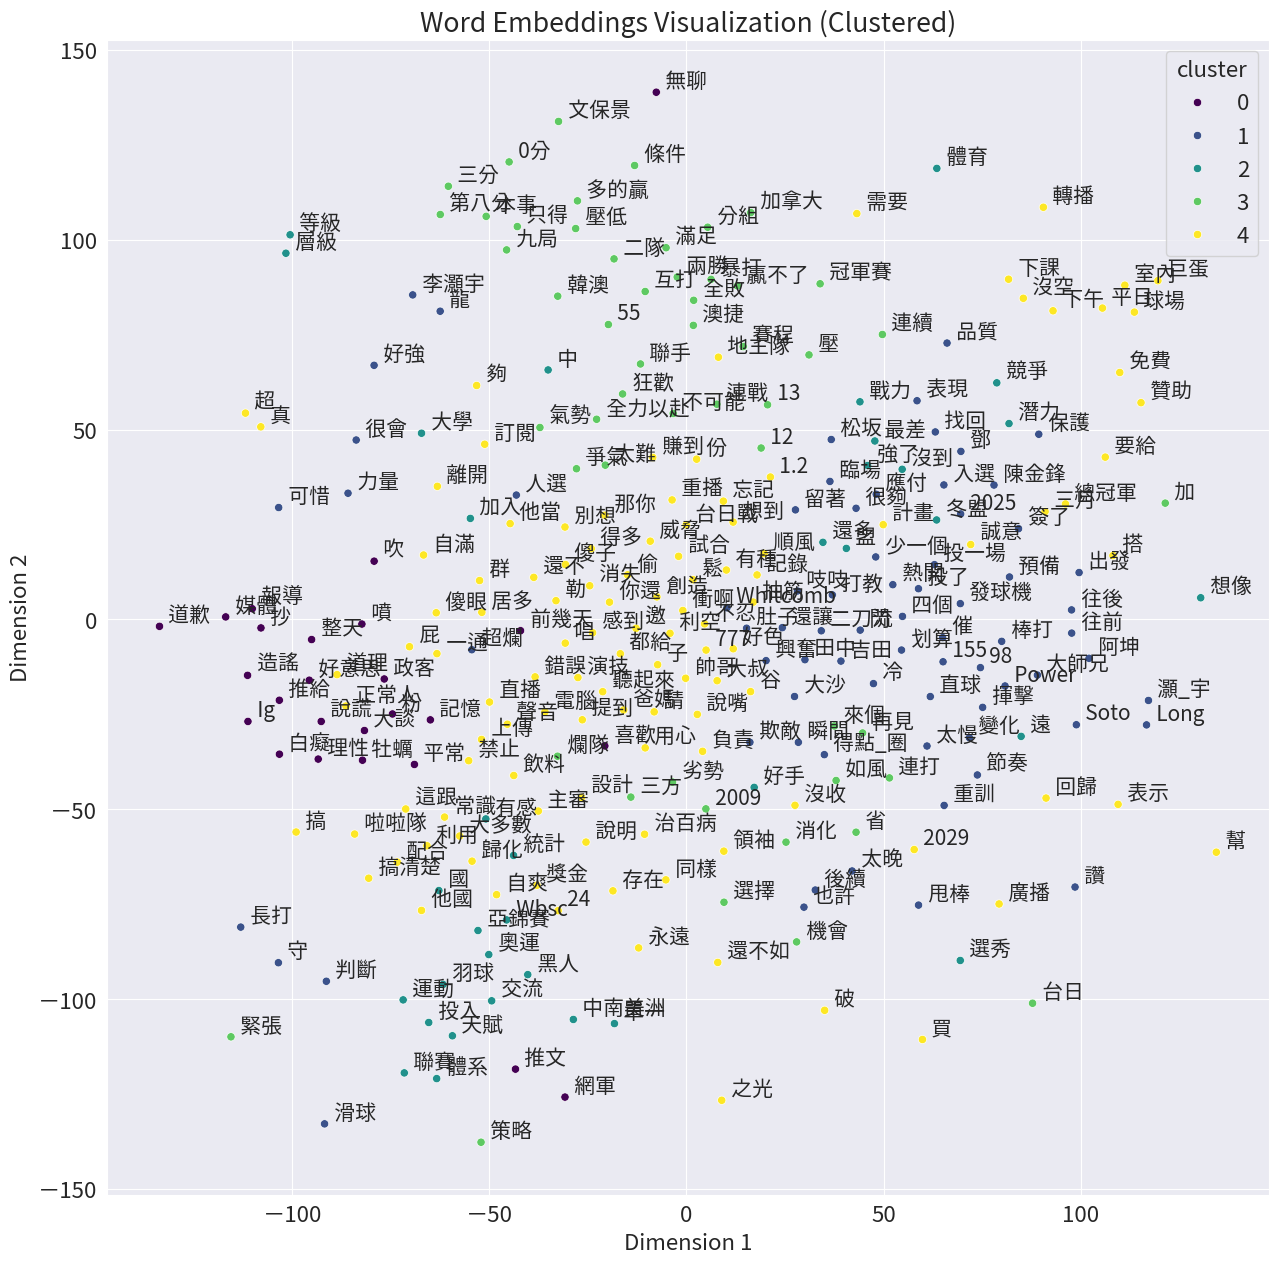

In [ ]:
from sklearn.cluster import KMeans

# Perform KMeans clustering
k = 5 # Number of clusters, this can be adjusted
kmeans_model = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=0, n_init=10)
clusters = kmeans_model.fit_predict(feat)

word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
    "cluster": clusters # Add cluster labels to the DataFrame
})

# Visualize with clusters
plotScatter(word_df, hue_column='cluster')

In [ ]:
new_feat = reduceDim(feat,dim = 3,method = 'PCA' )
print(new_feat.shape)
word_df = pd.DataFrame({
    "word":sample_words,
    "dim1":new_feat[:,0],
    "dim2":new_feat[:,1],
    "dim3":new_feat[:,2],
})
plotScatter3D(word_df)

(300, 3)


In [ ]:
!pip install scikit-learn-extra

# 強制重啟 Runtime，確保新安裝的套件被載入
import os
#os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 53.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=1959512 sha256=0ca5458ae2a4d911d8e83c8895f771d56b7cffcdff6ba19940196e0451b43c2a
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra


In [ ]:
# 分群
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
# 只使用word vector 去分群
def cluster(X,method = 'kmeans',n = 2):

    method_dict = {
        'kmeans':KMeans(n_clusters=n, random_state=0),
        'kmedos':KMedoids(n_clusters=n, random_state=0)
    }
    method_dict[method].fit(X)
    result = method_dict[method].predict(X)
    return result

In [ ]:
new_feat = reduceDim(feat,method='PCA',dim = 20)
d3_feat = reduceDim(feat,method='PCA',dim = 3)
word_df = pd.DataFrame({
    "word":sample_words,
    "color":cluster(new_feat,n=4),
    "dim1":d3_feat[:,0],
    "dim2":d3_feat[:,1],
    "dim3":d3_feat[:,2],

})
plotScatter3D(word_df)

### 使用embedding做NLP任務

In [ ]:
#PttWbcStopWordPath = os.path.join(base_path, 'raw_data/ptt_wbc_noStop_df.csv')
#origin_data = pd.read_csv(PttWbcStopWordPath)


#df_similar = origin_data[['system_id','artTitle', 'artContent']]
df_similar = origin_data[['artTitle', 'cmtContent', 'cmtDate', 'artDate']]
df_similar['artContent'] = df_similar['cmtContent'].apply(lambda x: re.sub('[^\u4e00-\u9fff]+', '',x))

df_similar.head(5)

/tmp/ipykernel_12332/2465862516.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,artTitle,cmtContent,cmtDate,artDate,artContent
0,[分享] MLB官網列出WBC每隊的關鍵球員,: 選近藤是因為可能會排在大谷後面嗎,2026-02-19 00:15:00+08:00,2026-02-19 00:13:52,選近藤是因為可能會排在大谷後面嗎
1,[分享] MLB官網列出WBC每隊的關鍵球員,: 希望徐的好表現讓大聯盟後悔沒簽下來,2026-02-19 00:19:00+08:00,2026-02-19 00:13:52,希望徐的好表現讓大聯盟後悔沒簽下來
2,[分享] MLB官網列出WBC每隊的關鍵球員,: 徐可以投長局數嗎？,2026-02-19 00:21:00+08:00,2026-02-19 00:13:52,徐可以投長局數嗎
3,[分享] MLB官網列出WBC每隊的關鍵球員,: Upper 90應該是95以上的意思？,2026-02-19 00:23:00+08:00,2026-02-19 00:13:52,應該是以上的意思
4,[分享] MLB官網列出WBC每隊的關鍵球員,: Upper 90 = high 90s 相對就是low 90s,2026-02-19 00:27:00+08:00,2026-02-19 00:13:52,相對就是


使用 Sentence-Transformer 套件

In [ ]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.7/588.7 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 7.3 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.9.4
    Uninstalling typer-0.9.4:
      Successfully uninstalled typer-0.9.4
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.4.1
    Uninstalling sentence-transformers-5.4.1:
      Successfully uninstalled sentence-transformers-5.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
weasel 0.3.4 requires typer<0.10.0,>=0.3.0, but you have typer 0.25.1 which is incompatible.
spacy 3.7.2 requires typer<0.10.0,>=0.3.0, but you have typer 0.25.1 which is incompatible.


In [ ]:
from sentence_transformers import SentenceTransformer, models, util

/tmp/ipykernel_12332/593637398.py:1: DeprecationWarning:

Importing from 'sentence_transformers.models' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.modules' instead.



Microsoft - Phi 4

In [ ]:
!pip install tiktoken
!pip install utils

  Preparing metadata (setup.py) ... done
  Created wheel for utils: filename=utils-1.0.2-py2.py3-none-any.whl size=13906 sha256=b581daa2d57a744937282a7186516da8f835c8d97fdab8610a1c8100d89fbe52
  Stored in directory: /root/.cache/pip/wheels/b6/a1/81/1036477786ae0e17b522f6f5a838f9bc4288d1016fc5d0e1ec
Successfully built utils


In [ ]:
# model_phi3 = SentenceTransformer('microsoft/Phi-3.5-mini-instruct')
model_phi4 = SentenceTransformer('microsoft/Phi-4-mini-instruct')

model_phi4.tokenizer.pad_token = model_phi4.tokenizer.eos_token

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



config.json: 0.00B [00:00, ?B/s]

This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/194 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/249 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

In [ ]:
# 中文 bert-base-chinese
bert_ch = SentenceTransformer('google-bert/bert-base-chinese', device='cuda')

bert_ch.tokenizer.add_special_tokens({'pad_token': '[PAD]'})

config.json:   0%|          | 0.00/624 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/412M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

0

In [ ]:
corpus_embeddings = bert_ch.encode(
    df_similar['artContent'].tolist(),
    convert_to_tensor=True,
    batch_size=32
)

In [ ]:
query_num = 6 # 指定文章

# Find the closest 5 sentences of the corpus for each query sentence based on cosine similarity
top_k = 50


query_embedding = bert_ch.encode(df_similar['artContent'][query_num], convert_to_tensor=True)

# We use cosine-similarity and torch.topk to find the highest 5 scores
cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
top_results = torch.topk(cos_scores, k=top_k)

print("\n\n======================\n\n")
print("Query:", df_similar['artTitle'][query_num])
print("\n 資料集中前五相似的文章:")

for score, idx in zip(top_results[0], top_results[1]):
    print(df_similar['artTitle'][idx.item()], "(Score: {:.4f})".format(score))

print("\n\n======================\n\n")





Query: [分享] MLB官網列出WBC每隊的關鍵球員

 資料集中前五相似的文章:
[分享] MLB官網列出WBC每隊的關鍵球員 (Score: 1.0000)
[分享] 柳志炫：年輕火球男淪為牛棚苦力 (Score: 0.8940)
Re: [討論] 陳冠偉指叉跟林詩翔變速，誰比較慘？ (Score: 0.8884)
[討論] 陳冠偉指叉跟林詩翔變速，誰比較慘？ (Score: 0.8882)
[討論] 中華隊首戰先發？ (Score: 0.8875)
[討論] 今日曾峻岳 4速球 5變化球 (Score: 0.8862)
[LIVE] 經典賽 中華 0：0 澳洲 3局下 (Score: 0.8854)
[討論] 韓國人大膽全面ABS影響國際賽表現？ (Score: 0.8854)
[分享] 今日 西武獅第四棒 林安可 (Score: 0.8840)
[問題] 臺灣有人面對160火球敲安打嗎? (Score: 0.8832)
[新聞] 經典賽前線／台日大戰對決山本由伸！ 費仔揭破解之道：保持紀律 (Score: 0.8829)
[新聞] 李大浩曝台灣打者致命弱點！解析揮棒軌 (Score: 0.8799)
[分享] 郭泓志對台韓大戰的感言 (Score: 0.8798)
[討論] 有人嘗試過在棒球遊戲乖乖選球嗎 (Score: 0.8794)
[討論] 村上有可能成為跟大谷同等級的選手嗎 (Score: 0.8791)
[討論] 覺得捷克比我們強是錯覺嗎？ (Score: 0.8787)
[LIVE] CPBL熱身賽#11 台鋼 VS 樂天 @斗六 (Score: 0.8785)
[新聞] WCY-井端警戒鄭浩均直球威力 喊話日本 (Score: 0.8782)
[LIVE] WBC韓國 vs 韓華鷹 G2 (Score: 0.8779)
[討論] 台灣土投普遍轉速不高? (Score: 0.8771)
[新聞] 經典賽／冠軍賽牛棚全員待命 委國教頭： (Score: 0.8770)
[討論] 伊藤大海站的穩MLB 先發輪值嗎? (Score: 0.8769)
[分享] 韓國隊先發投手：柳賢振 (Score: 0.8751)
[新聞] 經典賽》日媒關注莊陳仲敖「大谷攻略」 (Score: 0.8749)
[新聞] WBC》「只剩跑的功能我是最佳人選」

### 建立一個互動式函數，輸入文字後即可從資料集中搜尋最相似的文章

In [ ]:
def find_similar_articles_interactive(num_results=5):
    query_text = input("請輸入您想搜尋的文字或句子: ")

    # Encode the query
    query_embedding = bert_ch.encode(query_text, convert_to_tensor=True)

    # Compute cosine-similarity against all corpus embeddings
    cos_scores = util.cos_sim(query_embedding, corpus_embeddings)[0]
    top_results = torch.topk(cos_scores, k=num_results)

    print("\n======================\n")
    print(f"查詢文字: {query_text}")
    print(f"\n資料集中前 {num_results} 相似的文章:")

    for score, idx in zip(top_results[0], top_results[1]):
        print(f"標題: {df_similar['artTitle'][idx.item()]} (相似度分數: {score:.4f})")

    print("\n======================\n")

# 呼叫互動式函數來搜尋
find_similar_articles_interactive(num_results=5)

請輸入您想搜尋的文字或句子: 哪位教練調度最好


查詢文字: 哪位教練調度最好

資料集中前 5 相似的文章:
標題: [討論] 該檢討的是什麼 (相似度分數: 0.8757)
標題: [新聞] 遭多明尼加0：10無情扣倒 南韓媒體反應 (相似度分數: 0.8688)
標題: [討論] 美國派誰投冠軍很重要嗎? (相似度分數: 0.8663)
標題: [新聞] 不死鳥神之左腕重現！郭泓志隨隊親自餵 (相似度分數: 0.8619)
標題: [討論] 日本今晚太放鬆輸給澳洲呢？ (相似度分數: 0.8614)




In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_keyword_trend(keyword, df=df_similar):
    # 篩選包含關鍵字的評論
    keyword_articles = df[df['artContent'].str.contains(keyword, na=False)].copy()

    if keyword_articles.empty:
        print(f"資料集中未找到關鍵字 '{keyword}' 的相關文章。")
        return

    # 將日期轉換為日期格式，並提取日期部分
    keyword_articles['artDate_only'] = pd.to_datetime(keyword_articles['artDate']).dt.date

    # 依日期分組並計算文章數量
    daily_counts = keyword_articles.groupby('artDate_only').size().reset_index(name='article_count')

    # 確保日期是完整連續的，如果需要的話可以填充缺失日期為0
    # full_date_range = pd.date_range(start=daily_counts['artDate_only'].min(), end=daily_counts['artDate_only'].max())
    # daily_counts = daily_counts.set_index('artDate_only').reindex(full_date_range, fill_value=0).reset_index()
    # daily_counts.columns = ['artDate_only', 'article_count']

    # 繪製折線圖
    plt.figure(figsize=(15, 7))
    sns.lineplot(x='artDate_only', y='article_count', data=daily_counts, marker='o')

    plt.title(f"關鍵字 '{keyword}' 文章趨勢分析", fontsize=16)
    plt.xlabel('日期', fontsize=12)
    plt.ylabel('文章數量', fontsize=12)
    plt.xticks(rotation=45, ha='right') # 旋轉日期標籤以避免重疊
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


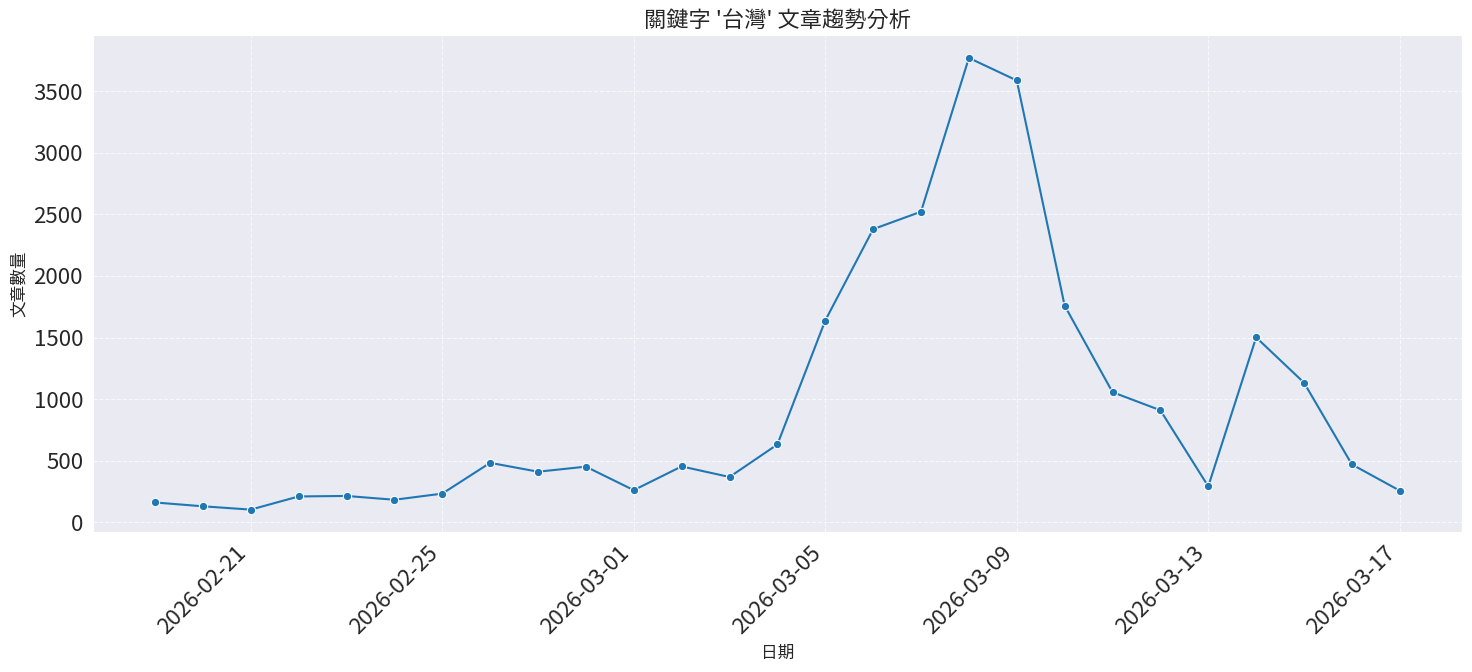

In [ ]:
# 範例：分析關鍵字 '台灣' 的趨勢
plot_keyword_trend('台灣')

# 您可以嘗試其他關鍵字，例如 '大谷' 或 '經典賽'
# plot_keyword_trend('大谷')
# plot_keyword_trend('經典賽')

In [ ]:
def analyze_keyword_daily_relevance(keyword, start_date_str, end_date_str, top_n=5):
    # 將日期字串轉換為 datetime 物件
    start_date = pd.to_datetime(start_date_str)
    end_date = pd.to_datetime(end_date_str)

    print(f"\n分析關鍵字: '{keyword}' 從 {start_date.strftime('%Y-%m-%d')} 到 {end_date.strftime('%Y-%m-%d')}")
    print("=" * 60)

    # 生成關鍵字的嵌入向量
    keyword_embedding = bert_ch.encode(keyword, convert_to_tensor=True)

    # 篩選在指定日期範圍內的文章副本
    # 使用 .copy() 以避免 SettingWithCopyWarning
    temp_df = df_similar[(df_similar['artDate'] >= start_date) & (df_similar['artDate'] <= end_date)].copy()

    if temp_df.empty:
        print(f"在指定日期範圍內未找到任何文章。")
        print("=" * 60)
        return

    # 確保 artDate_only 欄位存在
    temp_df['artDate_only'] = temp_df['artDate'].dt.date

    # 獲取篩選後 DataFrame 中唯一的日期，並進行排序
    unique_dates = sorted(temp_df['artDate_only'].unique())

    for current_date in unique_dates:
        print(f"\n日期: {current_date.strftime('%Y-%m-%d')}")
        daily_articles = temp_df[temp_df['artDate_only'] == current_date]

        # 獲取這些每日文章在原始 df_similar 中的索引
        original_indices = daily_articles.index.tolist()

        if not original_indices:
            print("  無相關文章。")
            continue

        # 從預先計算的 corpus_embeddings 中檢索這些每日文章的嵌入向量
        daily_embeddings = corpus_embeddings[original_indices]

        # 計算關鍵字嵌入向量與每日文章嵌入向量之間的餘弦相似度
        # unsqueeze(0) 用於將 keyword_embedding 轉換為 2D 張量 (1, embedding_dim)
        cos_scores = util.cos_sim(keyword_embedding.unsqueeze(0), daily_embeddings)[0]

        # 獲取當天最相關的 top_n 篇文章
        top_daily_results_scores, top_daily_results_indices = torch.topk(cos_scores, k=min(top_n, len(cos_scores)))

        if len(top_daily_results_scores) == 0:
            print("  無相關文章。")
        else:
            for score, idx_in_daily in zip(top_daily_results_scores, top_daily_results_indices):
                # 從原始的 df_similar 中獲取文章資訊
                original_df_index = original_indices[idx_in_daily.item()]
                article_title = df_similar.loc[original_df_index, 'artTitle']
                # 將文章內容取前 100 字作為摘要
                article_content_snippet = df_similar.loc[original_df_index, 'artContent'][:100]

                print(f"  相似度分數: {score:.4f}")
                print(f"  標題: {article_title}")
                print(f"  摘要: {article_content_snippet}...")
                print("  " + "-" * 20)

    print("\n" + "=" * 60)

# 範例用法：分析關鍵字 '經典賽' 從 '2026-03-01' 到 '2026-03-10' 的每日文章趨勢
# 您可以修改關鍵字、日期範圍和顯示的文章數量 (top_n)
# analyze_keyword_daily_relevance('經典賽', '2026-03-01', '2026-03-10', top_n=5)

In [ ]:
df_similar['artDate'] = pd.to_datetime(df_similar['artDate'])
analyze_keyword_daily_relevance("台灣打擊", "2026/2/28", "2026/3/17", top_n=5)

/tmp/ipykernel_12332/3714328189.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy




分析關鍵字: '台灣打擊' 從 2026-02-28 到 2026-03-17

日期: 2026-02-28
  相似度分數: 0.7875
  標題: [分享] 劉基鴻全壘打影片
  摘要: 日職球完全打擊聽牌中華隊...
  --------------------
  相似度分數: 0.7748
  標題: [新聞] WBC宮崎熱身賽天候變數 曾總：找方法維
  摘要: 打擊場暢打...
  --------------------
  相似度分數: 0.7687
  標題: [分享] 中華隊 經典賽歷年戰績
  摘要: 這國家棒球很...
  --------------------
  相似度分數: 0.7656
  標題: [新聞] WBC宮崎熱身賽天候變數 曾總：找方法維
  摘要: 大魯閣打擊場...
  --------------------
  相似度分數: 0.7604
  標題: [新聞] SPC-MLB》經典賽台灣關鍵主力！美媒揭李
  摘要: 中華隊二壘...
  --------------------

日期: 2026-03-01
  相似度分數: 0.7825
  標題: [情報] WBC禁止觀眾上傳照片影片
  摘要: 推廣棒球哈...
  --------------------
  相似度分數: 0.7637
  標題: [情報] WBC禁止觀眾上傳照片影片
  摘要: 日職也是鳥毛...
  --------------------
  相似度分數: 0.7552
  標題: [LIVE] Lotte交流賽 樂天巨人 vs 千葉羅德
  摘要: 打球...
  --------------------
  相似度分數: 0.7482
  標題: [分享] WBC運彩賠率 大降賠
  摘要: 台灣運彩...
  --------------------
  相似度分數: 0.7475
  標題: [新聞] 新北民代陳偉杰籲大巨蛋向北布局落腳淡
  摘要: 棒球...
  --------------------

日期: 2026-03-02
  相似度分數: 0.8280
  標題: [討論] 這屆韓國有比23義大利、荷蘭可怕嗎？
  摘要: 韓國打投...
  --------------------
  相似度分

In [ ]:
analyze_keyword_daily_relevance("台灣投手戰力", "2026/2/28", "2026/3/10", top_n=5)


分析關鍵字: '台灣投手戰力' 從 2026-02-28 到 2026-03-10

日期: 2026-02-28
  相似度分數: 0.8732
  標題: [討論] 中職找了許多洋投，怎麼打擊沒有起色？
  摘要: 日職投手比強...
  --------------------
  相似度分數: 0.8345
  標題: [新聞] 經典賽》觀戰台灣隊 葉總感嘆：以前只有
  摘要: 的投手事實...
  --------------------
  相似度分數: 0.8280
  標題: [討論] 中職找了許多洋投，怎麼打擊沒有起色？
  摘要: 因為日職投手洋投...
  --------------------
  相似度分數: 0.8198
  標題: [分享] 今日劉基鴻 十割男 鐵支
  摘要: 日職投手照打不誤...
  --------------------
  相似度分數: 0.8190
  標題: [LIVE] WBC澳洲 vs 橫濱DeNA
  摘要: 正選投手等級...
  --------------------

日期: 2026-03-01
  相似度分數: 0.8174
  標題: [問題] 爲何日職強打去MLB多數被鋸砲
  摘要: 投手場地球季長度訓練量...
  --------------------
  相似度分數: 0.8134
  標題: [新聞] 曾豪駒談官辦熱身賽中華隊投手調度 「張
  摘要: 大會支援投手是日職二軍嗎...
  --------------------
  相似度分數: 0.8128
  標題: [討論] 韓國必贏澳洲吧？
  摘要: 南韓用大聯盟投手對勝負很難說...
  --------------------
  相似度分數: 0.8037
  標題: [討論] 23日本隊比較強 還是26年日本隊比較強
  摘要: 投手超強打線完整...
  --------------------
  相似度分數: 0.7973
  標題: [新聞] YSF-扛首戰先發？林昱珉：有可能但還未定
  摘要: 韓國三位一位打者還有投手澳洲相比打線除狀...
  --------------------

日期: 2026-03-02
  相似度分數: 0.8459
  標題: [討論] 這屆韓國有比2

In [ ]:
analyze_keyword_daily_relevance("旅外球員", "2026/2/15", "2026/3/7", top_n=5)


分析關鍵字: '旅外球員' 從 2026-02-15 到 2026-03-07

日期: 2026-02-19
  相似度分數: 0.7685
  標題: [討論] 這幾年的澳洲到底是強隊還是弱隊??
  摘要: 本國職棒剛結束而已...
  --------------------
  相似度分數: 0.7656
  標題: [新聞] 經典賽／史上最強日本隊爆致命死穴！ 名
  摘要: 不具名的日本球界名宿...
  --------------------
  相似度分數: 0.7581
  標題: [新聞] 經典賽／史上最強日本隊爆致命死穴！ 名
  摘要: 拿球棒守備...
  --------------------
  相似度分數: 0.7536
  標題: [新聞] 古林睿煬動作稍跑掉 加入WBC集訓林岳平
  摘要: 日本教練...
  --------------------
  相似度分數: 0.7529
  標題: [討論] 這幾年的澳洲到底是強隊還是弱隊??
  摘要: 在中華隊面前都是爛隊...
  --------------------

日期: 2026-02-20
  相似度分數: 0.7896
  標題: [新聞] SPC-身披日本隊戰袍的台灣人！余聖傑：
  摘要: 隊的台籍教練徐志維...
  --------------------
  相似度分數: 0.7850
  標題: [新聞] SPC-身披日本隊戰袍的台灣人！余聖傑：
  摘要: 其他球類運動國家隊外教都很常見...
  --------------------
  相似度分數: 0.7781
  標題: [新聞] 直接點名台灣是預賽「最大強敵」 井端
  摘要: 能匹敵日職的投手在當教練...
  --------------------
  相似度分數: 0.7753
  標題: [新聞] 強打者擺在2棒就對了!台、日、韓三強所
  摘要: 中華隊二棒海誰來都可以...
  --------------------
  相似度分數: 0.7659
  標題: [新聞] SPC-身披日本隊戰袍的台灣人！余聖傑：
  摘要: 台灣國家隊是請過日籍教練酒井光次郎...
  --------------------

日期: 2026-02-21
  相似度分數: 0

### 7. Token classification

transformers 和 Sentence-transformers （使用 huggingface 模型）

#### 7.1 NER

In [2]:
#!pip install sentence_transformers
#!pip install ckip-transformers # Install the missing library

In [3]:
from transformers import BertTokenizerFast, AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification, pipeline
from sentence_transformers import SentenceTransformer
from ckip_transformers.nlp import CkipWordSegmenter, CkipPosTagger, CkipNerChunker

BERTopic

In [4]:
#!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.3 MB/s eta 0:00:00


In [5]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans

In [20]:
PttWbcStopWordPath = os.path.join(base_path, 'raw_data/ptt_wbc_noStop_df.csv')
origin_data = pd.read_csv(PttWbcStopWordPath)
origin_data.head(1)

,artTitle,artDate,artCatagory,cmtStatus,cmtDate,cmtContent,tokens_filtered,word
0,[分享] MLB官網列出WBC每隊的關鍵球員,2026-02-19 00:13:52,棒球,→,2026-02-19 00:15:00+08:00,: 選近藤是因為可能會排在大谷後面嗎,"['選', '近藤', '會排', '大谷', '後面']",選 近藤 會排 大谷 後面


In [14]:
from transformers import BertTokenizerFast, AutoModelForTokenClassification, pipeline

In [15]:
model_name = 'ckiplab/bert-base-chinese-ner'
tokenizer = BertTokenizerFast.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

ner_pipe = pipeline('ner', model=model, tokenizer=tokenizer)
example = ["在環遊世界的3年裡，威尼斯我最愛的城市。"]

ner_results = ner_pipe(example)
ner_results

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/407M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: ckiplab/bert-base-chinese-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/407M [00:00<?, ?B/s]

[[{'entity': 'B-DATE',
   'score': 0.9999993,
   'index': 7,
   'word': '3',
   'start': 6,
   'end': 7},
  {'entity': 'E-DATE',
   'score': 0.9999994,
   'index': 8,
   'word': '年',
   'start': 7,
   'end': 8},
  {'entity': 'B-GPE',
   'score': 0.99999833,
   'index': 11,
   'word': '威',
   'start': 10,
   'end': 11},
  {'entity': 'I-GPE',
   'score': 0.9999988,
   'index': 12,
   'word': '尼',
   'start': 11,
   'end': 12},
  {'entity': 'E-GPE',
   'score': 0.9999989,
   'index': 13,
   'word': '斯',
   'start': 12,
   'end': 13}]]

In [17]:
import pandas as pd
from ckip_transformers.nlp import CkipWordSegmenter, CkipPosTagger, CkipNerChunker

In [18]:
# Initialize metaData as it's used in subsequent cells
metaData = origin_data

# 初始化 ckip 工具
ws_driver  = CkipWordSegmenter(model_name="ckiplab/bert-base-chinese-ws", device=0)
pos_driver = CkipPosTagger(model_name="ckiplab/bert-base-chinese-pos", device=0)
ner_driver = CkipNerChunker(model_name="ckiplab/bert-base-chinese-ner", device=0)

# 執行 (assuming 'text' would be defined from metaData later, or provided by user)
# For now, `text` is undefined here, and will cause an error if executed without 'text'
# Consider defining `text` from an existing column in `metaData`, e.g., `metaData['cmtContent'].tolist()`
# ws = ws_driver(text)
# pos = pos_driver(ws)
# ner = ner_driver(text)

config.json:   0%|          | 0.00/804 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/407M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/407M [00:00<?, ?B/s]

BertForTokenClassification LOAD REPORT from: ckiplab/bert-base-chinese-ws
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: ckiplab/bert-base-chinese-ner
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [23]:
#text = metaData['sentence'].tolist() #cmtContent

#筆數太多隨機選個5000筆

text = metaData['cmtContent'].sample(n=5000, random_state=42).tolist()

# 執行
ws = ws_driver(text)
pos = pos_driver(ws)
ner = ner_driver(text)

# 將斷詞以及 pos 結果合在一起顯示
def pack_ws_pos_sentece(sentence_ws, sentence_pos):
   assert len(sentence_ws) == len(sentence_pos)
   res = []
   for word_ws, word_pos in zip(sentence_ws, sentence_pos):
      res.append(f"{word_ws}({word_pos})")
   return "\u3000".join(res)

sentences, packed_sentences, entities = [], [], []

# 儲存結果
for sentence, sentence_ws, sentence_pos, sentence_ner in zip(text, ws, pos, ner):
   sentences.append(sentence)
   packed_sentences.append(pack_ws_pos_sentece(sentence_ws, sentence_pos))
   entities.append([str(entity) for entity in sentence_ner])

# 將結果存在一個 dataframe 中
ner_results = pd.DataFrame({
   'sentence': sentences,
   'packed_sentence': packed_sentences,
   'entities': entities
})

ner_results

Inference: 100%|██████████| 20/20 [00:15<00:00,  1.33it/s]


,sentence,packed_sentence,entities
0,: 555的問題不是STUFF啊,:(COLONCATEGORY) 555(FW) 的(DE) 問題(Na) 不(D) 是(...,"[NerToken(word='555', ner='CARDINAL', idx=(2, ..."
1,: 日韓晉級本來就非常合理,:(COLONCATEGORY) (WHITESPACE) 日(Nc) 韓(Nc) 晉級(...,"[NerToken(word='日', ner='GPE', idx=(2, 3)), Ne..."
2,: 包機 門票 公務還是私人 隨扈，最沒問題的就是他有票,:(COLONCATEGORY) (WHITESPACE) 包機(Na) (WHITES...,[]
3,: 拉開分差用隅田、三分之內用宮城,:(COLONCATEGORY) (WHITESPACE) 拉開(VC) 分差(Na) 用...,[]
4,: 至少對方會纏,:(COLONCATEGORY) (WHITESPACE) 至少(Da) 對方(Nh) 會...,[]
...,...,...,...
4995,: 有 因為是WBC而且比較膠著,:(COLONCATEGORY) (WHITESPACE) 有(V_2) (WHITES...,[]
4996,: 不一樣了,:(COLONCATEGORY) (WHITESPACE) 不(D) 一樣(VH) 了(T),[]
4997,: 較勁才好看,:(COLONCATEGORY) (WHITESPACE) 較勁(VA) 才(Da) 好看...,[]
4998,: 又飛出來了？,:(COLONCATEGORY) (WHITESPACE) 又(D) 飛出來(VCL) 了...,[]


### 8. Sequence classification

#### 8.1 Sentiment Classification
使用 Huggingface 上面已經針對 Sentiment classification 任務 finetune 的 BERT 模型來實作<br>
使用的模型：https://huggingface.co/techthiyanes/chinese_sentiment<br><br>
情緒：<br>
1: Semi-negation<br>
2: Negation<br>
3: Neutral<br>
4: Semi-positive<br>
5: Positive

In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

# Load the specific sentiment analysis model
sentiment_model_name = 'techthiyanes/chinese_sentiment'
sentiment_tokenizer = AutoTokenizer.from_pretrained(sentiment_model_name)
sentiment_classifier_model = AutoModelForSequenceClassification.from_pretrained(sentiment_model_name)

# Create a sentiment analysis pipeline
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model=sentiment_classifier_model,
    tokenizer=sentiment_tokenizer
)

# 建立一個新的 dataframe 來儲存結果
results_df = pd.DataFrame(columns=['sentence', 'label', 'score'])
# 隨機挑選5000筆
results_df['sentence'] = metaData['cmtContent'].sample(n=5000, random_state=42).tolist()

# 定義一個函數來進行情緒分析，現在使用 sentiment_pipeline
def analyze_sentiment(sentence):
    # The pipeline returns a list of dictionaries, e.g., [{'label': 'LABEL_0', 'score': 0.99}]
    result = sentiment_pipeline(sentence)
    return pd.Series([result[0]['label'], result[0]['score']])

# 使用 apply 函數來進行情緒分析
results_df[['label', 'score']] = results_df['sentence'].apply(analyze_sentiment)

# 輸出結果
results_df

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: techthiyanes/chinese_sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,sentence,label,score
0,: 555的問題不是STUFF啊,star 2,0.307646
1,: 日韓晉級本來就非常合理,star 5,0.454259
2,: 包機 門票 公務還是私人 隨扈，最沒問題的就是他有票,star 5,0.319507
3,: 拉開分差用隅田、三分之內用宮城,star 4,0.422371
4,: 至少對方會纏,star 2,0.305040
...,...,...,...
4995,: 有 因為是WBC而且比較膠著,star 3,0.445819
4996,: 不一樣了,star 1,0.420265
4997,: 較勁才好看,star 4,0.305954
4998,: 又飛出來了？,star 2,0.423891


#### 8.2 Relation Extraction (RE)
使用 Huggingface 上面已經針對 RE 任務 finetune 的 BERT 模型來實作

In [27]:
tokenizer = AutoTokenizer.from_pretrained("teppei727/bert-large-relation14")
model = AutoModelForSequenceClassification.from_pretrained("teppei727/bert-large-relation14", ignore_mismatched_sizes=True)

re_model = pipeline("text-classification", model=model, tokenizer=tokenizer)

# 使用模型來進行 RE
text = [
    "My name is Wolfgang and I live in Berlin",
    "Obama was a USA president."
]
result = re_model(text)

# 輸出結果
result

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/369 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: teppei727/bert-large-relation14
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'label': '[no connective]', 'score': 0.5112523436546326},
 {'label': 'Expansion.Conjunction', 'score': 0.6735802888870239}]

In [30]:
# 建立一個新的 dataframe 來儲存結果

re_results_df = pd.DataFrame(columns=['sentence', 'label', 'score'])

# 隨機挑選5000筆
re_results_df['sentence'] = metaData['cmtContent'].sample(n=5000, random_state=42).tolist()
en_origin_data = re_results_df

# 定義一個函數來進行 RE 任務
def get_re_result(sentence):
    result = re_model([sentence])
    return pd.Series([result[0]['label'], result[0]['score']])

# 使用 apply 函數來進行 RE 任務
re_results_df[['label', 'score']] = en_origin_data['sentence'].apply(get_re_result)

# 輸出結果
re_results_df

,sentence,label,score
0,: 555的問題不是STUFF啊,Expansion.Instantiation.Arg2-as-instance,0.580161
1,: 日韓晉級本來就非常合理,Expansion.Instantiation.Arg2-as-instance,0.414318
2,: 包機 門票 公務還是私人 隨扈，最沒問題的就是他有票,Expansion.Instantiation.Arg2-as-instance,0.358165
3,: 拉開分差用隅田、三分之內用宮城,Expansion.Instantiation.Arg2-as-instance,0.392665
4,: 至少對方會纏,[no connective],0.518671
...,...,...,...
4995,: 有 因為是WBC而且比較膠著,Expansion.Instantiation.Arg2-as-instance,0.340130
4996,: 不一樣了,[no connective],0.541138
4997,: 較勁才好看,[no connective],0.619969
4998,: 又飛出來了？,[no connective],0.461585


### 9. Text Clustering

9.1 基本用法介紹

In [32]:
from hdbscan import HDBSCAN
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

In [33]:
docs = en_origin_data['sentence'].tolist()

# 定義不同 layer 所要使用的模型與方法
embedding_model = "all-MiniLM-L6-v2"
hdbscan_model = HDBSCAN()
vectorizer_model = CountVectorizer()

topic_model = BERTopic(embedding_model=embedding_model, hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model)
topics, probs = topic_model.fit_transform(docs[:500])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [34]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,91,-1_12強世界冠軍_活該_洪一中有一句名言_沒有失投的空間啊,"[12強世界冠軍, 活該, 洪一中有一句名言, 沒有失投的空間啊, 沒人在乎, 比捷克還低x...","[: 洪一中有一句名言：該給人家要給，不給的話，狀況可能會, : 包機 門票 公務還是私人 ..."
1,0,45,0_本來最重要就是韓國而已_歐洲一般人籃球打得不是很好_每天國頭七是不是啊_沒什麼好期待,"[本來最重要就是韓國而已, 歐洲一般人籃球打得不是很好, 每天國頭七是不是啊, 沒什麼好期待...","[: 惜敗日本海南、大勝捷克武里、險勝韓國陵南晉級，選我正解, : 如果有鄧愷威、卡仔、龍仔..."
2,1,26,1_555的問題不是stuff啊_還是要有三熊_這已經不是數學問題了_這個什麼焗烤又不是標準...,"[555的問題不是stuff啊, 還是要有三熊, 這已經不是數學問題了, 這個什麼焗烤又不是...","[: 好好笑，數學不好開始牽拖, : 假如 ，只是假如，台灣又賽到，完全會為南韓不值 也不削..."
3,2,26,2_什麼鳥用_你給翻譯翻譯_推這篇_推推推,"[什麼鳥用, 你給翻譯翻譯, 推這篇, 推推推, 守拉打位置, 好驚喜喔, 搞這個爛尾, 時...","[: 時差確實很傷, : 菜雞互啄, : 直練習]"
4,3,21,3_12強日本陣容差的不知道想啥_遇到日本投手就頂不起來了_賴本來就有在看棒球發文怎麼了嗎_...,"[12強日本陣容差的不知道想啥, 遇到日本投手就頂不起來了, 賴本來就有在看棒球發文怎麼了嗎...","[: 沒什麼好說的 事實上亞洲就是除了日本以外 其他都, : 以前人家是不屑參加wbc 日本..."
5,4,19,4_7吧老實說_三分之內用宮城_上季應該算完全體了_不只大谷,"[7吧老實說, 三分之內用宮城, 上季應該算完全體了, 不只大谷, 不期不待不受傷害, 井端...","[: 安可現在大概還在地下室 不期不待不受傷害, : 3:7吧老實說 大谷山本之外還是有差,..."
6,5,19,5_14k_這樣都能控到_超爽_給你彈球一樣揮不到啦,"[14k, 這樣都能控到, 超爽, 給你彈球一樣揮不到啦, 短期賽就是這樣啊, 短打都很棒,...","[: 咬來咬去 久了其實很膩 沒發現每屆組合根本都一樣?, : 14K 都揮不到球了 給你彈..."
7,6,19,6_in休假也要去看_今年可沒有家正欸_你們贏了有什麼用_其實聯盟強度大概就吃投手強度吃很重,"[in休假也要去看, 今年可沒有家正欸, 你們贏了有什麼用, 其實聯盟強度大概就吃投手強度吃...","[: 滿壘的星矢 好有期待感, : 我得8，會輸晉極跟輸球可能，我在7，我只有輸晉級可能, ..."
8,7,18,7_他會出現在休息室嗎_出局那次當作至寶_cy2投最弱的_875,"[他會出現在休息室嗎, 出局那次當作至寶, cy2投最弱的, 875, 體育是數學老師教的,...","[: 沒事 還沒對上可敬的對手台灣, : 這隻怎麼入選的 看成績沒很好, : 好像乙組讓甲組..."
9,8,18,8_12強mvp你敢嘴_7局8h2hr只掉那兩分_也明確表態支持abs_也沒用啊,"[12強mvp你敢嘴, 7局8h2hr只掉那兩分, 也明確表態支持abs, 也沒用啊, 他其...","[: 果改回去wbsc 那種用球跟秒數沒有特別設限。投手也, : 投手SS 但打擊B 也沒用..."


In [35]:
topic_model.get_topic(6)

[('in休假也要去看', 0.11224319433288245),
 ('今年可沒有家正欸', 0.11224319433288245),
 ('你們贏了有什麼用', 0.11224319433288245),
 ('其實聯盟強度大概就吃投手強度吃很重', 0.11224319433288245),
 ('去年也有啊xd', 0.11224319433288245),
 ('去年突然變身成明星', 0.11224319433288245),
 ('反觀我們的二壘手', 0.11224319433288245),
 ('反觀時差25小時的台灣才剛放大假回來', 0.11224319433288245),
 ('台灣分到大聯盟球場', 0.11224319433288245),
 ('好有期待感', 0.11224319433288245)]

In [36]:
topic_model.get_document_info(docs[:500])

,Document,Topic,Name,Representation,Representative_Docs,Top_n_words,Probability,Representative_document
0,: 555的問題不是STUFF啊,1,1_555的問題不是stuff啊_還是要有三熊_這已經不是數學問題了_這個什麼焗烤又不是標準...,"[555的問題不是stuff啊, 還是要有三熊, 這已經不是數學問題了, 這個什麼焗烤又不是...","[: 好好笑，數學不好開始牽拖, : 假如 ，只是假如，台灣又賽到，完全會為南韓不值 也不削...",555的問題不是stuff啊 - 還是要有三熊 - 這已經不是數學問題了 - 這個什麼焗烤又...,0.441899,False
1,: 日韓晉級本來就非常合理,3,3_12強日本陣容差的不知道想啥_遇到日本投手就頂不起來了_賴本來就有在看棒球發文怎麼了嗎_...,"[12強日本陣容差的不知道想啥, 遇到日本投手就頂不起來了, 賴本來就有在看棒球發文怎麼了嗎...","[: 沒什麼好說的 事實上亞洲就是除了日本以外 其他都, : 以前人家是不屑參加wbc 日本...",12強日本陣容差的不知道想啥 - 遇到日本投手就頂不起來了 - 賴本來就有在看棒球發文怎麼了...,1.000000,False
2,: 包機 門票 公務還是私人 隨扈，最沒問題的就是他有票,-1,-1_12強世界冠軍_活該_洪一中有一句名言_沒有失投的空間啊,"[12強世界冠軍, 活該, 洪一中有一句名言, 沒有失投的空間啊, 沒人在乎, 比捷克還低x...","[: 洪一中有一句名言：該給人家要給，不給的話，狀況可能會, : 包機 門票 公務還是私人 ...",12強世界冠軍 - 活該 - 洪一中有一句名言 - 沒有失投的空間啊 - 沒人在乎 - 比捷...,0.000000,True
3,: 拉開分差用隅田、三分之內用宮城,4,4_7吧老實說_三分之內用宮城_上季應該算完全體了_不只大谷,"[7吧老實說, 三分之內用宮城, 上季應該算完全體了, 不只大谷, 不期不待不受傷害, 井端...","[: 安可現在大概還在地下室 不期不待不受傷害, : 3:7吧老實說 大谷山本之外還是有差,...",7吧老實說 - 三分之內用宮城 - 上季應該算完全體了 - 不只大谷 - 不期不待不受傷害 ...,0.691552,False
4,: 至少對方會纏,-1,-1_12強世界冠軍_活該_洪一中有一句名言_沒有失投的空間啊,"[12強世界冠軍, 活該, 洪一中有一句名言, 沒有失投的空間啊, 沒人在乎, 比捷克還低x...","[: 洪一中有一句名言：該給人家要給，不給的話，狀況可能會, : 包機 門票 公務還是私人 ...",12強世界冠軍 - 活該 - 洪一中有一句名言 - 沒有失投的空間啊 - 沒人在乎 - 比捷...,0.000000,False
...,...,...,...,...,...,...,...,...
495,: 不是實力差距是計畫通 你先去私訊鄭宗哲,22,22_3a開季也能接受_打澳洲也打不出來_應該遲早會拉上去試一下到底是不是真貨_左打道奇,"[3a開季也能接受, 打澳洲也打不出來, 應該遲早會拉上去試一下到底是不是真貨, 左打道奇,...","[: 日本有不能輸的壓力沒錯 但對台也有不會輸的實力, : 宗哲 3A開季也能接受 但真的要...",3a開季也能接受 - 打澳洲也打不出來 - 應該遲早會拉上去試一下到底是不是真貨 - 左打道...,0.852766,False
496,: 為什麼要看低能的文 嘆~,23,23_9局_2017世大運還好沒thread_氣氛應該會不錯_比文保景拿香還值得玩味的,"[9局, 2017世大運還好沒thread, 氣氛應該會不錯, 比文保景拿香還值得玩味的, ...","[: 比文保景拿香還值得玩味的 其實是澳洲連續投紅中 因為, : 歡迎費仔，中華隊一堆E人原...",9局 - 2017世大運還好沒thread - 氣氛應該會不錯 - 比文保景拿香還值得玩味的...,1.000000,False
497,: 面試成功,6,6_in休假也要去看_今年可沒有家正欸_你們贏了有什麼用_其實聯盟強度大概就吃投手強度吃很重,"[in休假也要去看, 今年可沒有家正欸, 你們贏了有什麼用, 其實聯盟強度大概就吃投手強度吃...","[: 滿壘的星矢 好有期待感, : 我得8，會輸晉極跟輸球可能，我在7，我只有輸晉級可能, ...",in休假也要去看 - 今年可沒有家正欸 - 你們贏了有什麼用 - 其實聯盟強度大概就吃投手強...,0.696024,False
498,: 推,12,12____,"[, , , , , , , , , ]","[: 好, : 爽, : 汰]",- - - - - - - - -,0.889384,False


#### 9.2 Embedding model

In [38]:
from sentence_transformers import SentenceTransformer

In [39]:
# 使用 sentence_transformers 相關語言模型作為 embedding_model
sentence_model = SentenceTransformer("google-bert/bert-base-uncased")

# 定義不同 layer 所要使用的模型與方法
hdbscan_model = HDBSCAN()
vectorizer_model = CountVectorizer()

# 將 BERTopic 的 embedding_model 替換為其他模型（sentence_model）
embed_topic_model = BERTopic(embedding_model=sentence_model, hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model)
topics, probs = embed_topic_model.fit_transform(docs[:500])

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [42]:
embed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,136,-1_12強世界冠軍_短期賽就是這樣啊_短打都很棒_真的頗憨,"[12強世界冠軍, 短期賽就是這樣啊, 短打都很棒, 真的頗憨, 真的菜到不行, 真的莫名其...","[: 包機 門票 公務還是私人 隨扈，最沒問題的就是他有票, : 假如 ，只是假如，台灣又賽..."
1,0,22,0_ct卡費龍總來_88守備組_一擊炸裂_厚巴,"[ct卡費龍總來, 88守備組, 一擊炸裂, 厚巴, 先把生育率提升再說吧, 丟臉, 可憐井...","[: 拉進來 打出去, : 厚巴（歐巴）, : 神威啊 88守備組]"
2,1,22,1_一堆倒果為因的講再多也是跳針那幾句_道八強沒了_這樣林才可以放開投_這兩次國際賽最有感就...,"[一堆倒果為因的講再多也是跳針那幾句, 道八強沒了, 這樣林才可以放開投, 這兩次國際賽最有...","[: 道八強沒了 沒什麼好期待 只是沒想到最後贏韓國, : 魚養好 但費城上季超健康 上季應..."
3,2,20,2_3a開季也能接受_雖然台灣對美國的海外市場其實也蠻大的_連續十四年日職選秀有人獲選_能贏...,"[3a開季也能接受, 雖然台灣對美國的海外市場其實也蠻大的, 連續十四年日職選秀有人獲選, ...","[: 真的不太懂了 火力最大 不把DH讓給不太能守的？, : 不要不信季前的邦邦 左打道奇 ..."
4,3,19,3_三分之內用宮城_不只大谷_之前王牌都被陳金鋒打醒_人家根本不care小組賽,"[三分之內用宮城, 不只大谷, 之前王牌都被陳金鋒打醒, 人家根本不care小組賽, 加上4...","[: 南韓一定希望多明尼加輸，日本反過來, : 行李收收 宮崎報到, : 惜敗日本海南、大勝..."
5,4,18,4_dp_什麼_2沒壞_40,"[dp, 什麼, 2沒壞, 40, 笑死, 硬缸, 爽啦, 汪汪, 推這篇, 恭喜]","[: 汪汪：, : DP 強運, : 什麼 40:0]"
6,5,18,5_out_2b_請你否認_要被扣倒了,"[out, 2b, 請你否認, 要被扣倒了, 菜雞互啄, 胖卡布超嗨, 欸推錯了啦, 棒棒棒...","[: 退貨條款, : 搞這個爛尾…, : 1.2b 0 out 你在控啊]"
7,6,17,6_12強mvp你敢嘴_23年投手陣容真的滿爛的_不習慣_也沒用啊,"[12強mvp你敢嘴, 23年投手陣容真的滿爛的, 不習慣, 也沒用啊, 他要當補手龍貓也會...","[: 投手SS 但打擊B 也沒用啊, : 選手習慣台灣的氣候 到了日本 不習慣 狀態又會影響..."
8,7,17,7_14k_2023亞冠那套就很好看_mlb頂尖投手都未必能壓制住大谷了_mri都ok了,"[14k, 2023亞冠那套就很好看, mlb頂尖投手都未必能壓制住大谷了, mri都ok了...","[: 井端都說宮城大彌要接著上了 練打左投合理吧, : 14K 都揮不到球了 給你彈球一樣揮..."
9,8,17,8_大谷的極限確實是賽揚獎_奇兵最經典的就阿甘_半放推的_分差那麼多,"[大谷的極限確實是賽揚獎, 奇兵最經典的就阿甘, 半放推的, 分差那麼多, 出局那次當作至寶...","[: 這隻怎麼入選的 看成績沒很好, : 奇兵最經典的就阿甘 至於廖乙忠...半放推的, :..."


#### 9.3 Clustering model

In [44]:
from sklearn.cluster import KMeans

In [45]:
# 使用 KMeans 作為分群算法，需要指定分群個數
cluster_model = KMeans(n_clusters=10)

# 定義不同 layer 所要使用的模型與方法
embedding_model = "all-MiniLM-L6-v2"
vectorizer_model = CountVectorizer()

# 將 BERTopic 的 hdbscan_model 替換為其他模型（cluster_model）
kmeans_topic_model = BERTopic(embedding_model=embedding_model, hdbscan_model=cluster_model, vectorizer_model=vectorizer_model)
topics, probs = kmeans_topic_model.fit_transform(docs[:500])

kmeans_topic_model.get_topic_info()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Topic,Count,Name,Representation,Representative_Docs
0,0,100,0_0的含金量xdd_真的是拉基等級的那種_真的好看_真的不太懂了,"[0的含金量xdd, 真的是拉基等級的那種, 真的好看, 真的不太懂了, 真台灣人, 真假啦...","[: 真的不太懂了 火力最大 不把DH讓給不太能守的？, : 投手SS 但打擊B 也沒用啊,..."
1,1,71,1_7吧老實說_打得像完全沒情蒐_打支安打_打資格賽有啥不好,"[7吧老實說, 打得像完全沒情蒐, 打支安打, 打資格賽有啥不好, 放火就是井瓜, 日本人來...","[: 我得8，會輸晉極跟輸球可能，我在7，我只有輸晉級可能, : 包機 門票 公務還是私人 ..."
2,2,69,2_12強世界冠軍_狀態又會影響_物理傷害０_洪一中有一句名言,"[12強世界冠軍, 狀態又會影響, 物理傷害０, 洪一中有一句名言, 沒有運動家精神, 沒什...","[: 選手習慣台灣的氣候 到了日本 不習慣 狀態又會影響, : （抱歉 人在東京看球 網路怪..."
3,3,68,3_2沒壞_還以為會炸裂_這球打得好_這是常識好嗎,"[2沒壞, 還以為會炸裂, 這球打得好, 這是常識好嗎, 逆轉啦, 退貨條款, 身就很尷尬,...","[: 厚巴（歐巴）, : DP 強運, : 什麼 40:0]"
4,4,56,4_14k_如果王貞治時代有經典賽_字體不行啦_完全會為南韓不值,"[14k, 如果王貞治時代有經典賽, 字體不行啦, 完全會為南韓不值, 就不會被單局10分,...","[: 不打迷最偉大啦 MRI都ok了 球團一句話你就不能打 不然哩, : 又沒錢領 洪愛當 ..."
5,5,49,5_林立_歐洲一般人籃球打得不是很好_每天國頭七是不是啊_沒什麼好期待,"[林立, 歐洲一般人籃球打得不是很好, 每天國頭七是不是啊, 沒什麼好期待, 沒問題吧, 派...","[: 惜敗日本海南、大勝捷克武里、險勝韓國陵南晉級，選我正解, : 如果有鄧愷威、卡仔、龍仔..."
6,6,38,6_2017世大運還好沒thread_支持中華隊_文大哥_文杰qq,"[2017世大運還好沒thread, 支持中華隊, 文大哥, 文杰qq, 文胎哥, 林凱威這...","[: 歡迎費仔，中華隊一堆E人原民選手，氣氛應該會不錯。, : 中職只看到四爺一堆廣告 龍貓..."
7,7,24,7_2026了_2023亞冠那套就很好看_辛苦了_跟少宏至關重要,"[2026了, 2023亞冠那套就很好看, 辛苦了, 跟少宏至關重要, 超過100分, 超準...","[: 2026了, : 亞洲在ig講兩句就被說丟臉了 何況是打架 反觀啥?, : 1.2b ..."
8,8,15,8_777777_7777777777_96_gg,"[777777, 7777777777, 96, gg, 更正, 100, 4444, 77...","[: 100, : 777777, : Gg]"
9,9,10,9_這樣怎麼去mlb_這個分配才是對的_跨國訴訟_趕快去mlb吧,"[這樣怎麼去mlb, 這個分配才是對的, 跨國訴訟, 趕快去mlb吧, 能選進來是精英, 日...","[: 世界怎麼跟著上中職 領先MLB30年, : 跨國訴訟？我支持喔，MLB的法務團隊打季後..."


In [46]:
topics[:10]

[4, 2, 1, 2, 0, 1, 1, 1, 0, 5]

#### 9.4 套用於中文

In [53]:
# 中文文章
docs_zh = metaData['cmtContent'].tolist()[:500]

# 1. 定義基礎路徑 (建議使用絕對路徑避免混淆)
base_path = '/content/drive/MyDrive/中山大學/SMA_2026S-main/week11'

# 2. 設定詞庫路徑
dict_path = os.path.join(base_path, 'dict/dict.txt.big')
user_dict_path = os.path.join(base_path, 'dict/user_dict.txt')
stopword_path = os.path.join(base_path, 'dict/stopwords.txt')

# 3. 載入 jieba 設定
jieba.set_dictionary(dict_path)
jieba.load_userdict(user_dict_path)

# 4. 讀取 stopwords
with open(stopword_path, 'r', encoding='utf-8') as f:
    stopWords = [line.strip() for line in f.readlines()]

# 設定中文 embedding model
bert_sentence_model = SentenceTransformer("google-bert/bert-base-chinese")

# 將中文文章轉換為 embedding
embeddings = bert_sentence_model.encode(docs_zh, show_progress_bar=True)

# 定義不同 clustering layer 所要使用的模型與方法（就用 default 的 HDBSCAN）
hdbscan_model = HDBSCAN()

# 定義一個適合中文的分詞函數
def tokenize_zh(text):
    words = jieba.lcut(text)
    return words

# 建立一個使用 jieba 分詞的 CountVectorizer
jieba_vectorizer = CountVectorizer(tokenizer=tokenize_zh, stop_words=stopWords, analyzer='word', token_pattern=u"(?u)\\b\\w+\\b")

# 使用 BERTopic 進行主題模型建立
zh_topic_model = BERTopic(embedding_model=bert_sentence_model, vectorizer_model=jieba_vectorizer, verbose=True, top_n_words=30)
topics, probs = zh_topic_model.fit_transform(docs_zh, embeddings)

zh_topic_model.get_topic_info()

Building prefix dict from /content/drive/MyDrive/中山大學/SMA_2026S-main/week11/dict/dict.txt.big ...
DEBUG:jieba:Building prefix dict from /content/drive/MyDrive/中山大學/SMA_2026S-main/week11/dict/dict.txt.big ...
Loading model from cache /tmp/jieba.u02da0a2c6f2d9d35f746c5fde228c877.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.u02da0a2c6f2d9d35f746c5fde228c877.cache
Loading model cost 2.998 seconds.
DEBUG:jieba:Loading model cost 2.998 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-chinese
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

2026-05-21 13:31:12,016 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-21 13:31:13,922 - BERTopic - Dimensionality - Completed ✓
2026-05-21 13:31:13,923 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-21 13:31:13,949 - BERTopic - Cluster - Completed ✓
2026-05-21 13:31:13,956 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-21 13:31:14,048 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1,-1_happy_be_to_here,"[happy, be, to, here, , , , , , , , , , , , ,...",[: Happy to be here]
1,0,338,0_ _幸災樂禍_韓國_台灣,"[ , 幸災樂禍, 韓國, 台灣, 參加, 志在, 台, 真的, 大谷, 古林, tv, 爽...","[: 台灣人幸災樂禍, : 哪個不重要…, : 問題不大]"
2,1,81,1_ _推_推推_讚,"[ , 推, 推推, 讚, 用心, 超, 猛, 有心, 謝謝, 利多, 好慘, 網站, 厲害...","[: 推很讚, : 哈, : 重要？]"
3,2,28,2_推_ _讚_push,"[推, , 讚, push, 誒, 推個, , , , , , , , , , , , ,...","[: 推, : 推, : 推]"
4,3,26,3_ _幸_kanazawa_sports,"[ , 幸, kanazawa, sports, 格賽, firestone, 布, 電, ...","[: 會, : 多, : 了]"
5,4,26,4_推_ __,"[推, , , , , , , , , , , , , , , , , , , , , ,...","[: 推, : 推, : 推]"


In [54]:
zh_topic_model.visualize_topics()

查看特定文章的主題分佈

In [55]:
topic_distr, _ = zh_topic_model.approximate_distribution(docs_zh)

100%|██████████| 1/1 [00:00<00:00,  4.49it/s]


In [56]:
zh_topic_model.visualize_distribution(topic_distr[18])

In [57]:
zh_topic_model.get_topic(2)

[('推', 0.5328087312889549),
 (' ', 0.22486764017599623),
 ('讚', 0.12769824174310473),
 ('push', 0.07366981098907845),
 ('誒', 0.07366981098907845),
 ('推個', 0.06544247887253811),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05),
 ('', 1e-05)]

In [59]:
# 設定字體
fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
plt.rcParams['font.sans-serif'] = ['Taipei Sans TC Beta']
plt.rcParams['font.size'] = '16'

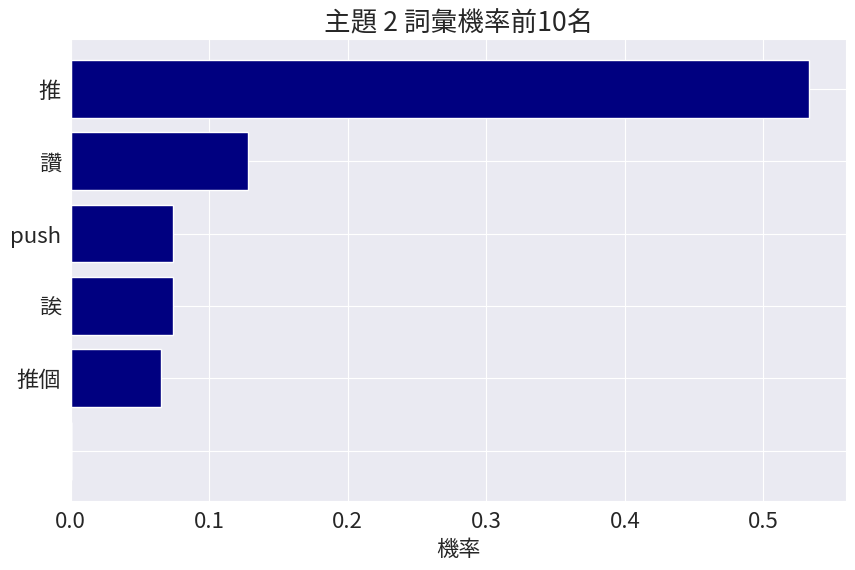

In [62]:
# 視覺化顯示主題-詞彙分佈
topic_n = 2
data = zh_topic_model.get_topic(topic_n)

# 轉換為DataFrame
df = pd.DataFrame(data, columns=['word', 'prob'])
df = df[df['word'] != ' ']

# 根據prob排序並選出前10名
top_10 = df.sort_values('prob', ascending=False).head(10)

# 畫出長條圖
plt.figure(figsize=(10,6))
plt.barh(top_10['word'], top_10['prob'], color='navy')
plt.xlabel('機率')
plt.title(f'主題 {topic_n} 詞彙機率前10名')
plt.gca().invert_yaxis()
plt.show()